# 🛢️ Sprint 1: Adquisición y Validación de Datos
**Proyecto:** Análisis de la Dinámica Productiva en la Cuenca Cuyana  
**Objetivo de este notebook:** Cargar los datos crudos, explorar la estructura, aislar los registros de la Cuenca Cuyana (Mendoza), tratar valores faltantes y generar las primeras variables derivadas (como la fecha de primera producción).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configuración visual básica
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Definimos la ruta donde tu compañero guardó el archivo procesado de la auditoría
RUTA_DATOS = "../data/processed/produccion_pozos_cuenca_cuyana_2021_2026.csv"

## 1. Explorar columnas y diccionario de datos
Cargamos el dataset histórico consolidado y revisamos sus tipos de datos.

In [4]:
# Carga de datos
df = pd.read_csv(RUTA_DATOS)

# Exploración inicial
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.info())
display(df.describe().T)

Filas: 246240 | Columnas: 38
<class 'pandas.DataFrame'>
RangeIndex: 246240 entries, 0 to 246239
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               246240 non-null  str    
 1   anio                    246240 non-null  int64  
 2   mes                     246240 non-null  int64  
 3   idpozo                  246240 non-null  int64  
 4   prod_pet                246240 non-null  float64
 5   prod_gas                246240 non-null  float64
 6   prod_agua               246240 non-null  float64
 7   iny_agua                246240 non-null  float64
 8   iny_gas                 246240 non-null  float64
 9   iny_co2                 246240 non-null  float64
 10  iny_otro                246240 non-null  float64
 11  tef                     246240 non-null  float64
 12  vida_util               15525 non-null   float64
 13  tipoextraccion          246240 non-null  str    
 14  ti

None

,count,mean,std,min,25%,50%,75%,max
anio,246240.0,2023.317495,1.623234,2021.0,2022.0,2023.0,2025.00,2026.00
mes,246240.0,6.241309,3.415961,1.0,3.0,6.0,9.00,12.00
idpozo,246240.0,119576.223501,27702.114278,596.0,122646.0,123578.0,124519.00,167276.00
prod_pet,246240.0,22.100513,59.121913,0.0,0.0,0.0,0.00,1245.60
prod_gas,246240.0,1.042237,3.966390,0.0,0.0,0.0,0.00,657.22
prod_agua,246240.0,710.086137,2401.554691,0.0,0.0,0.0,0.00,28221.28
iny_agua,246240.0,705.662538,5571.317121,0.0,0.0,0.0,0.00,218837.80
iny_gas,246240.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.00
iny_co2,246240.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.00
iny_otro,246240.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.00


## 2. Filtrar e identificar registros (Foco en Mendoza)
Validamos que estamos trabajando con la Cuenca Cuyana y limitamos el alcance a la provincia de Mendoza para nuestro análisis.


In [5]:
# Validamos las cuencas y provincias disponibles
print("Distribución por Cuenca:\n", df['cuenca'].value_counts())
print("\nDistribución por Provincia:\n", df['provincia'].value_counts())

# Filtramos estrictamente Mendoza si hay pozos de otras provincias en la cuenca
df_mendoza = df[df['provincia'] == 'Mendoza'].copy()
print(f"\nPozos únicos en Mendoza: {df_mendoza['idpozo'].nunique()}")

Distribución por Cuenca:
 cuenca
CUYANA    246240
Name: count, dtype: int64

Distribución por Provincia:
 provincia
Mendoza    246240
Name: count, dtype: int64

Pozos únicos en Mendoza: 3702


## 3. Evaluar identificador único y continuidad mensual
Verificamos que `idpozo` sea consistente y calculamos cuántos meses de datos tiene cada pozo para saber si sirven para el análisis de maduración.

In [6]:
# Check de duplicados exactos por mes y pozo
duplicados = df_mendoza.duplicated(subset=['idpozo', 'anio', 'mes']).sum()
print(f"Registros duplicados por pozo-mes: {duplicados}")

# Continuidad: ¿Cuántos meses de registro tiene cada pozo?
meses_por_pozo = df_mendoza.groupby('idpozo').size()
display(meses_por_pozo.describe())

# Clasificamos la completitud
df_mendoza['meses_registrados'] = df_mendoza.groupby('idpozo')['idpozo'].transform('count')

Registros duplicados por pozo-mes: 0


count    3702.000000
mean       66.515397
std         4.770967
min         4.000000
25%        67.000000
50%        67.000000
75%        67.000000
max        68.000000
dtype: float64

## 4. Detectar fecha de primera producción
Buscamos el primer mes cronológico en el que el pozo reportó una producción de petróleo mayor a cero.

In [7]:
# Aseguramos que la fecha sea formato datetime
df_mendoza['fecha_data'] = pd.to_datetime(df_mendoza['fecha_data'])

# Filtramos solo los meses donde hubo producción real
df_prod_activa = df_mendoza[df_mendoza['prod_pet'] > 0]

# Buscamos la fecha mínima por pozo
fecha_primera_prod = df_prod_activa.groupby('idpozo')['fecha_data'].min().reset_index()
fecha_primera_prod.rename(columns={'fecha_data': 'fecha_primera_produccion'}, inplace=True)

# Unimos esta nueva variable al dataset original
df_mendoza = df_mendoza.merge(fecha_primera_prod, on='idpozo', how='left')
df_mendoza[['idpozo', 'fecha_data', 'prod_pet', 'fecha_primera_produccion']].head()

,idpozo,fecha_data,prod_pet,fecha_primera_produccion
0,162019,2021-01-31,0.00,NaT
1,160838,2021-01-31,91.23,2021-01-31
2,160267,2021-01-31,32.58,2021-01-31
3,160265,2021-01-31,843.53,2021-01-31
4,160142,2021-01-31,37.81,2021-01-31


## 5. Clasificación y Separación de Recursos
Analizamos la proporción de Convencional vs No Convencional y definimos columnas de interés.

In [8]:
# Proporción de tipo de recurso
print(df_mendoza['tipo_de_recurso'].value_counts(normalize=True) * 100)

# Para este proyecto, nos centraremos principalmente en:
columnas_clave = [
    'idpozo', 'fecha_data', 'anio', 'mes', 'areayacimiento', 
    'prod_pet', 'prod_gas', 'prod_agua', 'tipo_de_recurso', 
    'fecha_primera_produccion'
]
df_limpio = df_mendoza[columnas_clave].copy()

tipo_de_recurso
CONVENCIONAL    100.0
Name: proportion, dtype: float64


## 6. Reporte de Faltantes y Outliers
Evaluamos la calidad final de nuestro dataset reducido.

In [9]:
# Cuantificar nulos
print("Reporte de Valores Nulos:\n", df_limpio.isnull().sum())

# Detectar valores imposibles (ej. producción negativa)
prod_negativa = df_limpio[df_limpio['prod_pet'] < 0]
print(f"\nRegistros con producción de petróleo negativa: {len(prod_negativa)}")

# Limpieza básica de inconsistencias si existieran
df_limpio['prod_pet'] = df_limpio['prod_pet'].clip(lower=0) 
df_limpio['prod_gas'] = df_limpio['prod_gas'].clip(lower=0)

Reporte de Valores Nulos:
 idpozo                           0
fecha_data                       0
anio                             0
mes                              0
areayacimiento                   0
prod_pet                         0
prod_gas                         0
prod_agua                        0
tipo_de_recurso                  0
fecha_primera_produccion    172722
dtype: int64

Registros con producción de petróleo negativa: 0


## 7. Validación del criterio de filtrado geográfico (Cuenca vs. Provincia)

Se compara el filtro por cuenca == 'CUYANA' (el definido como universo del proyecto en el contexto maestro) contra el filtro por provincia == 'Mendoza' (usado en la exploración inicial de Sprint 1), para confirmar si ambos producen el mismo subconjunto de datos antes de construir las tablas de análisis. Esto evita arrastrar una inconsistencia de alcance geográfico a los resultados finales.

In [10]:
import pandas as pd

df = pd.read_csv("../data/processed/produccion_pozos_cuenca_cuyana_2021_2026.csv")

pozos_cuenca = df[df['cuenca'] == 'CUYANA']['idpozo'].nunique()
pozos_mendoza = df[df['provincia'] == 'Mendoza']['idpozo'].nunique()
pozos_interseccion = df[(df['cuenca'] == 'CUYANA') & (df['provincia'] == 'Mendoza')]['idpozo'].nunique()

print(f"Pozos por cuenca == CUYANA: {pozos_cuenca}")
print(f"Pozos por provincia == Mendoza: {pozos_mendoza}")
print(f"Pozos que cumplen ambas condiciones: {pozos_interseccion}")

# ¿Hay pozos de Cuyana en otras provincias (San Juan, La Rioja)?
print(df[df['cuenca'] == 'CUYANA']['provincia'].value_counts())

# ¿Hay pozos en Mendoza que NO son de la Cuenca Cuyana?
print(df[df['provincia'] == 'Mendoza']['cuenca'].value_counts())

Pozos por cuenca == CUYANA: 3702
Pozos por provincia == Mendoza: 3702
Pozos que cumplen ambas condiciones: 3702
provincia
Mendoza    246240
Name: count, dtype: int64
cuenca
CUYANA    246240
Name: count, dtype: int64


Se validó que el filtro por cuenca == 'CUYANA' y por provincia == 'Mendoza' producen exactamente el mismo conjunto de 3.702 pozos únicos, sin registros exclusivos de ninguno de los dos criterios. Esto confirma que, para el período y dataset analizados, toda la Cuenca Cuyana corresponde a la provincia de Mendoza y viceversa. Se adopta cuenca == 'CUYANA' como criterio de filtrado oficial del proyecto, por ser el que coincide con la definición de universo establecida en el contexto maestro, aunque el resultado sería idéntico usando provincia == 'Mendoza'.

In [11]:
# Filtro oficial del proyecto (equivalente al de provincia, pero alineado a la definición del contexto maestro)
df_cuyana = df[df['cuenca'] == 'CUYANA'].copy()
print(f"Pozos únicos en Cuyana: {df_cuyana['idpozo'].nunique()}")

Pozos únicos en Cuyana: 3702


## 8: Tabla Macro (Cuenca Cuyana / tiempo)

Se agrega el dataset a nivel año-mes para obtener la evolución histórica de producción total, cantidad de pozos activos y pozos nuevos por período — la base para el análisis de la Línea 1 (resiliencia/evolución productiva).

In [12]:
df_cuyana['fecha_data'] = pd.to_datetime(df_cuyana['fecha_data'])

df_macro = (
    df_cuyana
    .groupby(["anio", "mes"])
    .agg(
        produccion_petroleo=("prod_pet", "sum"),
        produccion_gas=("prod_gas", "sum"),
        pozos_activos=("idpozo", "nunique")
    )
    .reset_index()
)

# Pozos nuevos por mes: primera aparición de cada pozo en el histórico
primer_registro = df_cuyana.groupby("idpozo")[["anio", "mes"]].min().reset_index()
pozos_nuevos = primer_registro.groupby(["anio", "mes"]).size().reset_index(name="pozos_nuevos")

df_macro = df_macro.merge(pozos_nuevos, on=["anio", "mes"], how="left")
df_macro["pozos_nuevos"] = df_macro["pozos_nuevos"].fillna(0).astype(int)

df_macro.to_csv("../data/processed/tabla_macro_cuyana.csv", index=False)
df_macro.head()

,anio,mes,produccion_petroleo,produccion_gas,pozos_activos,pozos_nuevos
0,2021,1,96999.971498,3998.416434,3660,3673
1,2021,2,83233.670986,3505.785425,3577,0
2,2021,3,93288.301759,3937.385785,3664,0
3,2021,4,94448.064233,3922.123445,3664,0
4,2021,5,98521.937118,4081.578993,3667,0


## 9. Tabla Micro (pozo / mes)

Se confirma que el dataset filtrado ya tiene granularidad de una fila por pozo-mes, y se seleccionan las columnas relevantes con su metadata (yacimiento, recurso), dejando la base lista para feature engineering y el análisis de ramp-up de la Línea 2.

In [13]:
duplicados = df_cuyana.duplicated(subset=["idpozo", "anio", "mes"]).sum()
print("Duplicados pozo-mes:", duplicados)  # debería dar 0

columnas_clave = [
    'idpozo', 'fecha_data', 'anio', 'mes', 'areayacimiento',
    'prod_pet', 'prod_gas', 'prod_agua', 'tipo_de_recurso'
]
df_micro = df_cuyana[columnas_clave].copy()

df_micro.to_csv("../data/processed/tabla_micro_cuyana.csv", index=False)
df_micro.head()

Duplicados pozo-mes: 0


,idpozo,fecha_data,anio,mes,areayacimiento,prod_pet,prod_gas,prod_agua,tipo_de_recurso
0,162019,2021-01-31,2021,1,UGARTECHE,0.00,0.00,235.47,CONVENCIONAL
1,160838,2021-01-31,2021,1,UGARTECHE,91.23,3.23,10.23,CONVENCIONAL
2,160267,2021-01-31,2021,1,UGARTECHE,32.58,1.20,83.11,CONVENCIONAL
3,160265,2021-01-31,2021,1,MESA VERDE,843.53,30.47,313.61,CONVENCIONAL
4,160142,2021-01-31,2021,1,LA VENTANA CENTRAL,37.81,2.10,189.83,CONVENCIONAL


## 10. Evolución histórica de producción (Línea 1)

Se grafica la serie temporal completa de producción (petróleo y gas por separado) y la evolución de pozos activos/nuevos, con observaciones escritas para identificar visualmente los períodos de crecimiento, caída o estabilidad.

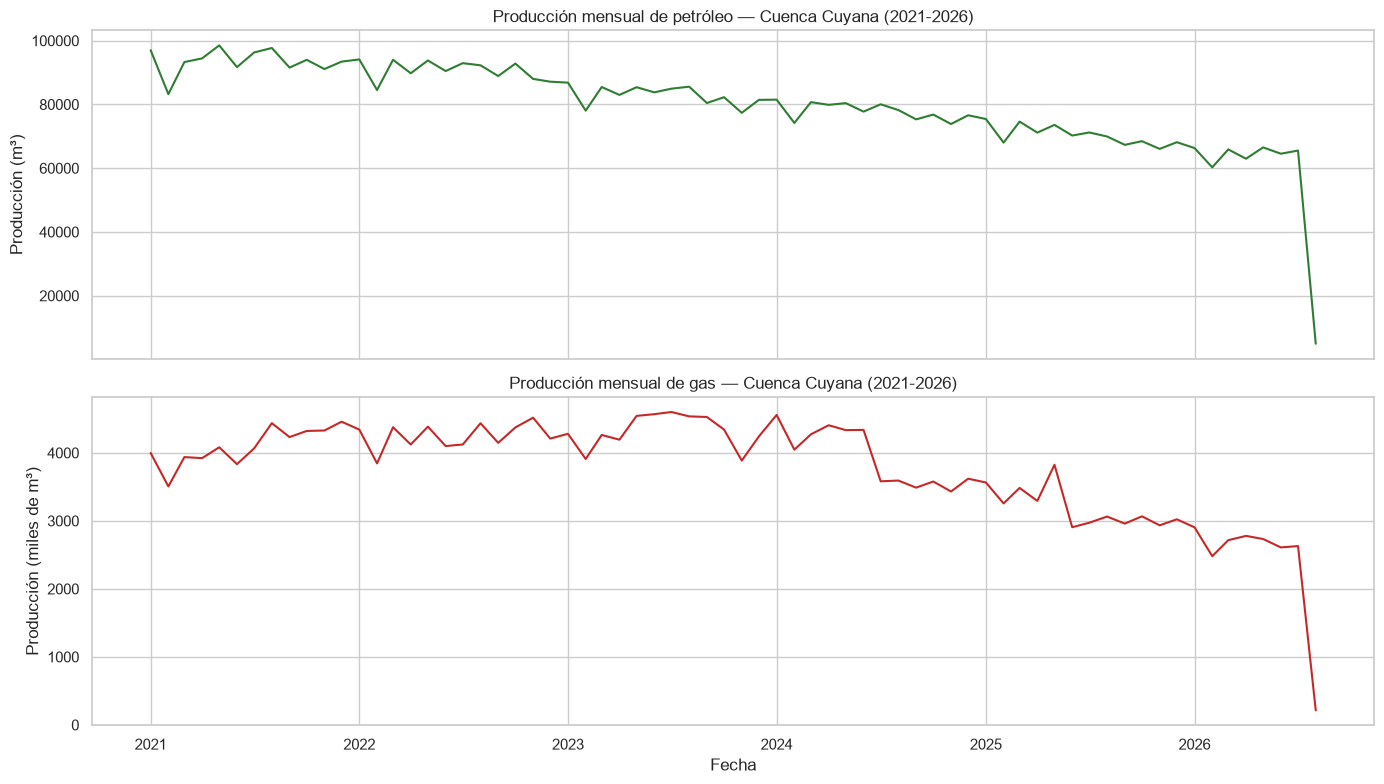

In [14]:
df_macro['fecha'] = pd.to_datetime(df_macro['anio'].astype(str) + '-' + df_macro['mes'].astype(str) + '-01')
df_macro = df_macro.sort_values('fecha')

# --- Gráfico 1: Producción total de petróleo y gas ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_macro['fecha'], df_macro['produccion_petroleo'], color='#2E7D32')
axes[0].set_title('Producción mensual de petróleo — Cuenca Cuyana (2021-2026)')
axes[0].set_ylabel('Producción (m³)')

axes[1].plot(df_macro['fecha'], df_macro['produccion_gas'], color='#C62828')
axes[1].set_title('Producción mensual de gas — Cuenca Cuyana (2021-2026)')
axes[1].set_ylabel('Producción (miles de m³)')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

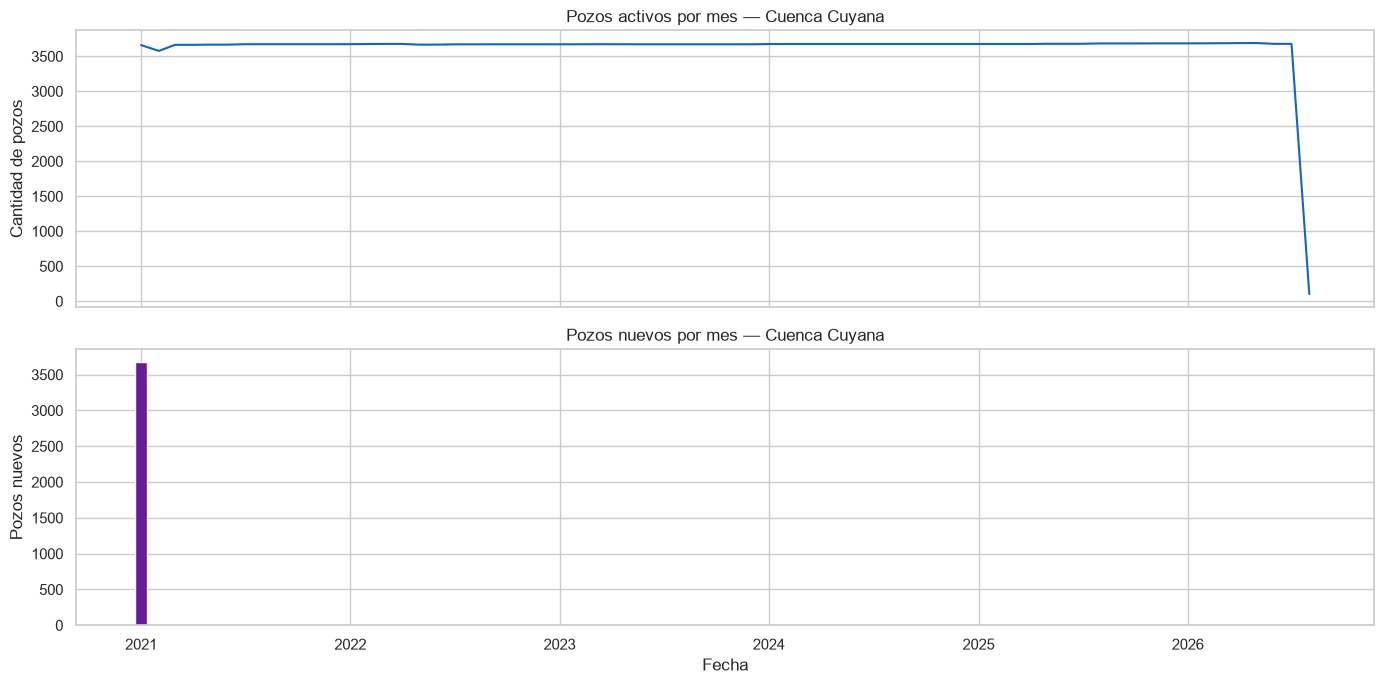

In [15]:
# --- Gráfico 2: Pozos activos y pozos nuevos por mes ---
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df_macro['fecha'], df_macro['pozos_activos'], color='#1565C0')
axes[0].set_title('Pozos activos por mes — Cuenca Cuyana')
axes[0].set_ylabel('Cantidad de pozos')

axes[1].bar(df_macro['fecha'], df_macro['pozos_nuevos'], width=20, color='#6A1B9A')
axes[1].set_title('Pozos nuevos por mes — Cuenca Cuyana')
axes[1].set_ylabel('Pozos nuevos')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

### Observaciones — Evolución histórica de producción (Línea 1)

**Producción de petróleo y gas:**
- Se observa una tendencia de **declinación sostenida y gradual** en la producción 
  de petróleo a lo largo de todo el período 2021-2026, pasando de valores cercanos 
  a 95.000-100.000 m³ mensuales a inicios de 2021 hasta aproximadamente 60.000-65.000 m³ 
  hacia el final del período analizado. La producción de gas muestra un patrón similar, 
  cayendo de un rango de 4.000-4.500 miles de m³ a valores cercanos a 2.600-3.000.
- No se identifican períodos de crecimiento sostenido: la serie muestra micro-oscilaciones 
  mes a mes (estacionalidad o variabilidad operativa) sobre una tendencia de fondo 
  claramente descendente, sin cambios de régimen abruptos salvo el quiebre final.
- **El desplome final que se observa en ambos gráficos (hacia fines de 2026) es un 
  artefacto de datos, no un hallazgo real**: corresponde al período parcial de 2026 
  (8 meses, con declaraciones juradas "abiertas y cerradas" que pueden incluir datos 
  aún no consolidados). Se recomienda excluir o marcar por separado el tramo de 2026 
  en los gráficos y análisis siguientes para no distorsionar la lectura de la tendencia.

**Pozos activos y pozos nuevos:**
- La cantidad de pozos activos se mantiene **notablemente estable**, oscilando en un 
  rango angosto de aproximadamente 3.600 a 3.700 pozos durante prácticamente todo el 
  período, lo que indica que la declinación de producción observada arriba **no se 
  explica por una caída en la cantidad de pozos operativos**, sino por una caída en 
  el rendimiento promedio por pozo (declinación natural de los yacimientos).
- **El pico de "pozos nuevos" concentrado en el primer mes de 2021 es un artefacto 
  metodológico del dataset, no un hallazgo productivo real**: corresponde a que 2021 
  es el primer año cubierto por el histórico, por lo que todos los pozos ya existentes 
  se registran como "primera aparición" ese mes. La cantidad real de pozos nuevos 
  perforados durante 2021-2026 es la que ya se había identificado en la auditoría 
  inicial (42 pozos en total en ese período), muy por debajo de lo que sugiere este 
  gráfico sin corregir.

**Conclusión para la Línea 1:**
La Cuenca Cuyana muestra un comportamiento de **declinación productiva estable y 
progresiva**, sostenida por una base de pozos activos prácticamente constante — es 
decir, el patrón dominante es de **agotamiento gradual de pozos maduros**, no de 
volatilidad ni de expansión productiva, en el período 2021-2025 (excluyendo el tramo 
parcial de 2026).

## 11. EDA — Producción vs Brent (contexto de mercado)

In [25]:
import os

archivos = os.listdir("../data/raw/03_contexto_macro/")
for archivo in archivos:
    print(archivo)

argentina_oil_gas_dataset_final.csv
pozos-en-perforacin.csv
pozos-terminados.csv
precio_internacional.xlsx
produccin-de-gas-promedio-diaria-por-cuenca.csv
produccin-de-petrleo-promedio-diaria-por-cuenca.csv
serie-histrica-de-produccin-de-gas-natural-por-cuenca-y-sub-tipo-de-recurso-captulo-iv-.csv


In [27]:
%pip install openpyxl
df_brent = pd.read_excel("../data/raw/03_contexto_macro/precio_internacional.xlsx")

print(df_brent.shape)
print(df_brent.columns.tolist())
df_brent.head(10)

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.
(82, 4)
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Precio internacional de petróleo (*),NaN,NaN
1,NaN,Fecha de publicación,U$S/barril,Vigencia desde
2,NaN,2026-08-31 00:00:00,89.17,2026-09-01 00:00:00
3,NaN,2026-07-31 00:00:00,88.468,2026-08-01 00:00:00
4,NaN,2026-06-30 00:00:00,73.41,2026-07-01 00:00:00
5,NaN,2026-05-29 00:00:00,95.15,2026-06-01 00:00:00
6,NaN,2026-04-30 00:00:00,111.312,2026-05-01 00:00:00
7,NaN,2026-03-31 00:00:00,107.64,2026-04-01 00:00:00
8,NaN,2026-03-13 00:00:00,89.834,2026-03-16 00:00:00
9,NaN,2026-02-27 00:00:00,71.296,2026-03-01 00:00:00


In [28]:
df_brent = pd.read_excel(
    "../data/raw/03_contexto_macro/precio_internacional.xlsx",
    skiprows=2,        # salta la fila de título y la fila vacía inicial
    usecols="B:D"      # toma solo las columnas con datos reales (fecha, precio, vigencia)
)

df_brent.columns = ["fecha_publicacion", "precio_usd_barril", "fecha_vigencia"]
df_brent = df_brent.dropna(subset=["precio_usd_barril"])  # por si queda alguna fila basura

df_brent["fecha_publicacion"] = pd.to_datetime(df_brent["fecha_publicacion"])
df_brent["fecha_vigencia"] = pd.to_datetime(df_brent["fecha_vigencia"])

print(df_brent.shape)
df_brent.head(10)

(79, 3)


,fecha_publicacion,precio_usd_barril,fecha_vigencia
0,2026-08-31,89.170,2026-09-01
1,2026-07-31,88.468,2026-08-01
2,2026-06-30,73.410,2026-07-01
3,2026-05-29,95.150,2026-06-01
4,2026-04-30,111.312,2026-05-01
5,2026-03-31,107.640,2026-04-01
6,2026-03-13,89.834,2026-03-16
7,2026-02-27,71.296,2026-03-01
8,2026-01-30,68.610,2026-02-01
9,2025-12-30,61.834,2026-01-01


Un par de cosas importantes que salen de mirar los datos:

La granularidad no es mensual limpia — hay varias publicaciones en el mismo mes (por ejemplo dos entradas para marzo 2026: una del 13/03 y otra del 27/02 con "vigencia desde" 16/03 y 01/03 respectivamente). Esto parece ser un precio que se actualiza más de una vez por mes, no una serie mensual fija. Para poder cruzarlo con tu df_macro (que sí es mensual, un valor por año-mes), vas a necesitar agregarlo a mensual primero — por ejemplo, tomando el promedio o el último valor vigente de cada mes:

In [29]:
df_brent["anio"] = df_brent["fecha_vigencia"].dt.year
df_brent["mes"] = df_brent["fecha_vigencia"].dt.month

df_brent_mensual = (
    df_brent
    .groupby(["anio", "mes"])["precio_usd_barril"]
    .mean()  # o .last() si preferís el último precio vigente del mes
    .reset_index()
    .rename(columns={"precio_usd_barril": "brent_usd"})
)

df_brent_mensual.head()

,anio,mes,brent_usd
0,2020,5,31.520
1,2020,6,35.372
2,2020,7,41.750
3,2020,8,43.332
4,2020,9,45.350


In [30]:
print("Desde:", df_brent_mensual[["anio","mes"]].min().to_dict())
print("Hasta:", df_brent_mensual[["anio","mes"]].max().to_dict())
print("Cantidad de meses:", len(df_brent_mensual))

Desde: {'anio': 2020, 'mes': 1}
Hasta: {'anio': 2026, 'mes': 12}
Cantidad de meses: 77


el precio internacional cubre desde enero 2020 hasta diciembre 2026, lo que significa que cubre de sobra todo tu período de producción (2021-2026), sin huecos. Podés avanzar tranquila con el merge y el gráfico.

In [32]:
# Merge: tu tabla macro (producción) + precio internacional mensual
df_macro['fecha'] = pd.to_datetime(df_macro['anio'].astype(str) + '-' + df_macro['mes'].astype(str) + '-01')

df_macro_precio = df_macro.merge(
    df_brent_mensual,
    on=['anio', 'mes'],
    how='left'
)

# Chequeo rápido de que el merge no dejó nulos donde no debería
print("Meses sin precio asignado:", df_macro_precio['brent_usd'].isna().sum())
df_macro_precio.head()

Meses sin precio asignado: 0


,anio,mes,produccion_petroleo,produccion_gas,pozos_activos,pozos_nuevos,fecha,brent_usd
0,2021,1,96999.971498,3998.416434,3660,3673,2021-01-01,50.90
1,2021,2,83233.670986,3505.785425,3577,0,2021-02-01,55.71
2,2021,3,93288.301759,3937.385785,3664,0,2021-03-01,65.49
3,2021,4,94448.064233,3922.123445,3664,0,2021-04-01,64.01
4,2021,5,98521.937118,4081.578993,3667,0,2021-05-01,66.80


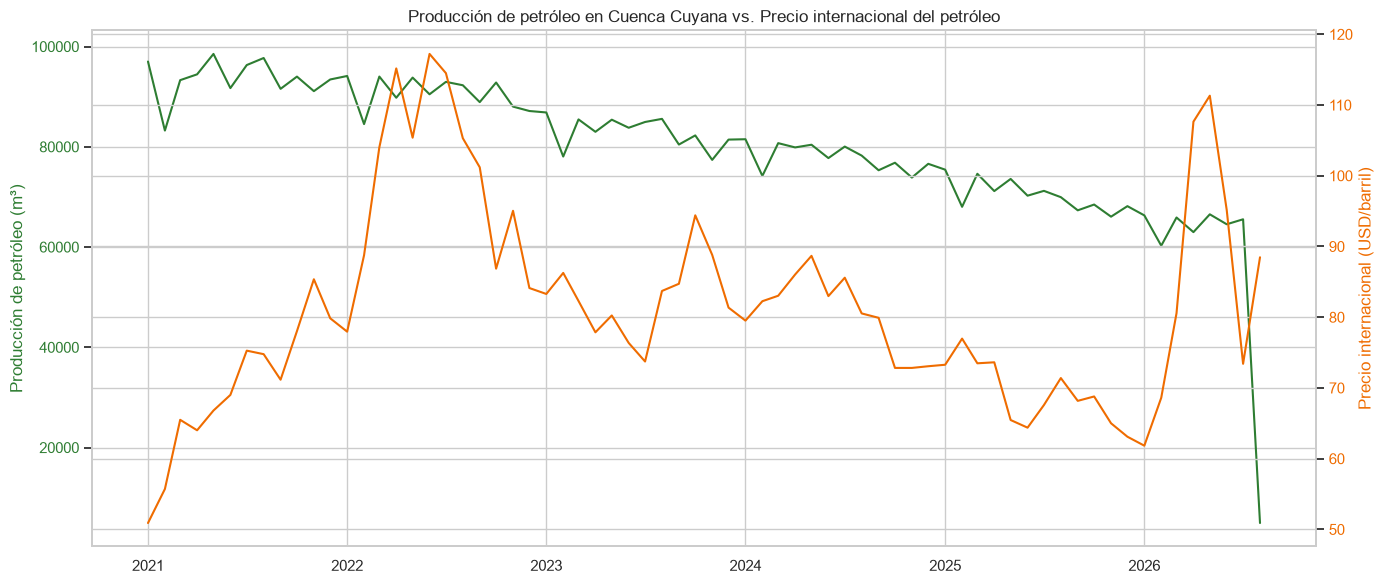

In [33]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_macro_precio['fecha'], df_macro_precio['produccion_petroleo'], color='#2E7D32', label='Producción petróleo')
ax1.set_ylabel('Producción de petróleo (m³)', color='#2E7D32')
ax1.tick_params(axis='y', labelcolor='#2E7D32')

ax2 = ax1.twinx()
ax2.plot(df_macro_precio['fecha'], df_macro_precio['brent_usd'], color='#EF6C00', label='Precio internacional (USD/barril)')
ax2.set_ylabel('Precio internacional (USD/barril)', color='#EF6C00')
ax2.tick_params(axis='y', labelcolor='#EF6C00')

plt.title('Producción de petróleo en Cuenca Cuyana vs. Precio internacional del petróleo')
fig.tight_layout()
plt.show()

In [34]:
# Exploración de rezagos (lag) — solo visual, sin asumir causalidad
for lag in [0, 1, 3, 6]:
    corr = df_macro_precio['produccion_petroleo'].corr(df_macro_precio['brent_usd'].shift(lag))
    print(f"Correlación con precio internacional rezagado {lag} meses: {corr:.3f}")

Correlación con precio internacional rezagado 0 meses: 0.089
Correlación con precio internacional rezagado 1 meses: 0.200
Correlación con precio internacional rezagado 3 meses: -0.013
Correlación con precio internacional rezagado 6 meses: 0.246


### Observaciones — Producción vs. Precio internacional del petróleo

**Comportamiento visual:**
- La producción de petróleo muestra la tendencia decreciente y estable ya 
  identificada en la Línea 1, prácticamente indiferente a las fluctuaciones 
  del precio internacional.
- El precio internacional, en cambio, es mucho más volátil: sube de forma 
  pronunciada desde valores cercanos a 50 USD/barril a comienzos de 2021 
  hasta un pico de aproximadamente 110 USD/barril a mediados de 2022, y 
  luego oscila en un rango de 60-90 USD/barril con caídas y repuntes marcados 
  durante 2023-2026.
- No se observa un acompañamiento visual claro entre ambas series: mientras 
  el precio sube fuertemente en 2022, la producción no muestra una reacción 
  equivalente (sigue en su tendencia declinante ya iniciada).
- **El quiebre abrupto al final de ambas series (fines de 2026) es el mismo 
  artefacto de datos ya documentado en la Línea 1** (año parcial con DDJJ 
  abiertas/cerradas) y no debe interpretarse como un hallazgo real de mercado 
  ni de producción.

**Correlación con rezagos (lag):**
| Rezago | Correlación |
|---|---|
| 0 meses | 0.089 |
| 1 mes | 0.200 |
| 3 meses | -0.013 |
| 6 meses | 0.246 |

- Las correlaciones son **débiles en todos los rezagos evaluados** (el valor 
  más alto es 0.246 a 6 meses, muy lejos de indicar una relación fuerte).
- No hay un patrón creciente y consistente a medida que aumenta el rezago 
  (pasa de 0.089 a 0.200, cae a -0.013, y vuelve a subir a 0.246), lo que 
  sugiere que estas correlaciones son probablemente ruido estadístico más 
  que una señal real de relación con rezago.

**Conclusión para esta sección:**
En el período y granularidad analizados, **la producción de petróleo de la 
Cuenca Cuyana no muestra una relación clara ni consistente con el precio 
internacional del petróleo**, ni de forma contemporánea ni con rezagos de 
hasta 6 meses. Esto es consistente con la naturaleza de la producción de 
pozos maduros en declinación: las decisiones de producción a este nivel 
agregado parecen estar más determinadas por la curva natural de declinación 
de los yacimientos que por señales de corto plazo del mercado internacional. 
Este resultado es preliminar y exploratorio; no se descarta que a nivel de 
yacimiento u operador individual sí existan relaciones más marcadas que se 
diluyen en el agregado de toda la cuenca.

### Nota metodológica
Este análisis es exploratorio. La correlación observada entre producción y 
precio internacional del petróleo (con o sin rezago) no implica una relación 
causal, y en este caso las correlaciones encontradas son débiles. El precio 
se incorpora únicamente como variable de contexto de mercado.

Nota sobre la fuente: el archivo utilizado se titula "Precio internacional de 
petróleo" (fuente: Secretaría de Energía); no se confirmó si corresponde 
específicamente al benchmark Brent u otra referencia, por lo que se lo 
denomina de forma genérica en este análisis.

## 12. EDA — Curvas de producción por pozo (Línea 2)

se incorpora la fecha de primera producción de cada pozo (desde el padrón), se calcula cuántos meses lleva cada pozo desde su inicio, y se grafica una muestra representativa de curvas individuales para identificar visualmente el patrón de ramp-up → pico → declive.

In [35]:
# Cargar el padrón con fecha de primera producción (si no lo tenés ya cargado en esta rama)
padron = pd.read_csv("../data/raw/02_padrones/padrn-de-pozos-de-captulo-iv-con-fecha-de-primera-produccin.csv")

padron_cuyana = padron[padron['idpozo'].isin(df_micro['idpozo'].unique())].copy()
padron_cuyana = padron_cuyana.rename(columns={'anio': 'anio_inicio', 'mes': 'mes_inicio'})

print("Pozos de Cuyana con fecha en el padrón:", len(padron_cuyana))
print("Pozos de Cuyana en df_micro:", df_micro['idpozo'].nunique())

Pozos de Cuyana con fecha en el padrón: 3702
Pozos de Cuyana en df_micro: 3702


In [36]:
# Unir fecha de inicio a df_micro y calcular meses transcurridos desde el inicio
df_micro_curvas = df_micro.merge(padron_cuyana[['idpozo', 'anio_inicio', 'mes_inicio']], on='idpozo', how='left')

df_micro_curvas['meses_desde_inicio'] = (
    (df_micro_curvas['anio'] - df_micro_curvas['anio_inicio']) * 12
    + (df_micro_curvas['mes'] - df_micro_curvas['mes_inicio'])
)

# Descartamos registros previos a la fecha de inicio (por si hay inconsistencias)
df_micro_curvas = df_micro_curvas[df_micro_curvas['meses_desde_inicio'] >= 0]

In [37]:
# Elegir una muestra representativa: pozos con más historial disponible,
# priorizando los que iniciaron dentro del período 2021-2026 (los "nuevos" reales)
pozos_por_historial = (
    df_micro_curvas.groupby('idpozo')['meses_desde_inicio']
    .max()
    .sort_values(ascending=False)
)

# Muestra de 12 pozos con buen historial, para la galería
muestra_pozos = pozos_por_historial.head(12).index.tolist()

In [41]:
# Identificar los pozos con fecha de inicio real dentro de 2021-2026 (no la fecha artificial de 2006)
pozos_rampup_reales = padron_cuyana[padron_cuyana['anio_inicio'].between(2021, 2026)]['idpozo'].tolist()
print(f"Pozos con inicio real 2021-2026: {len(pozos_rampup_reales)}")

Pozos con inicio real 2021-2026: 42


In [42]:
# Filtrar solo los pozos con inicio real 2021-2026 Y con algo de producción de petróleo
pozos_rampup_con_datos = (
    df_micro_curvas[
        df_micro_curvas['idpozo'].isin(pozos_rampup_reales)
    ]
    .groupby('idpozo')['prod_pet']
    .sum()
)

# Nos quedamos solo con los que sí produjeron petróleo (descartar pozos de gas puro)
pozos_rampup_con_datos = pozos_rampup_con_datos[pozos_rampup_con_datos > 0].sort_values(ascending=False)

print(f"Pozos de ramp-up real con producción de petróleo: {len(pozos_rampup_con_datos)}")
muestra_rampup = pozos_rampup_con_datos.head(12).index.tolist()

Pozos de ramp-up real con producción de petróleo: 16


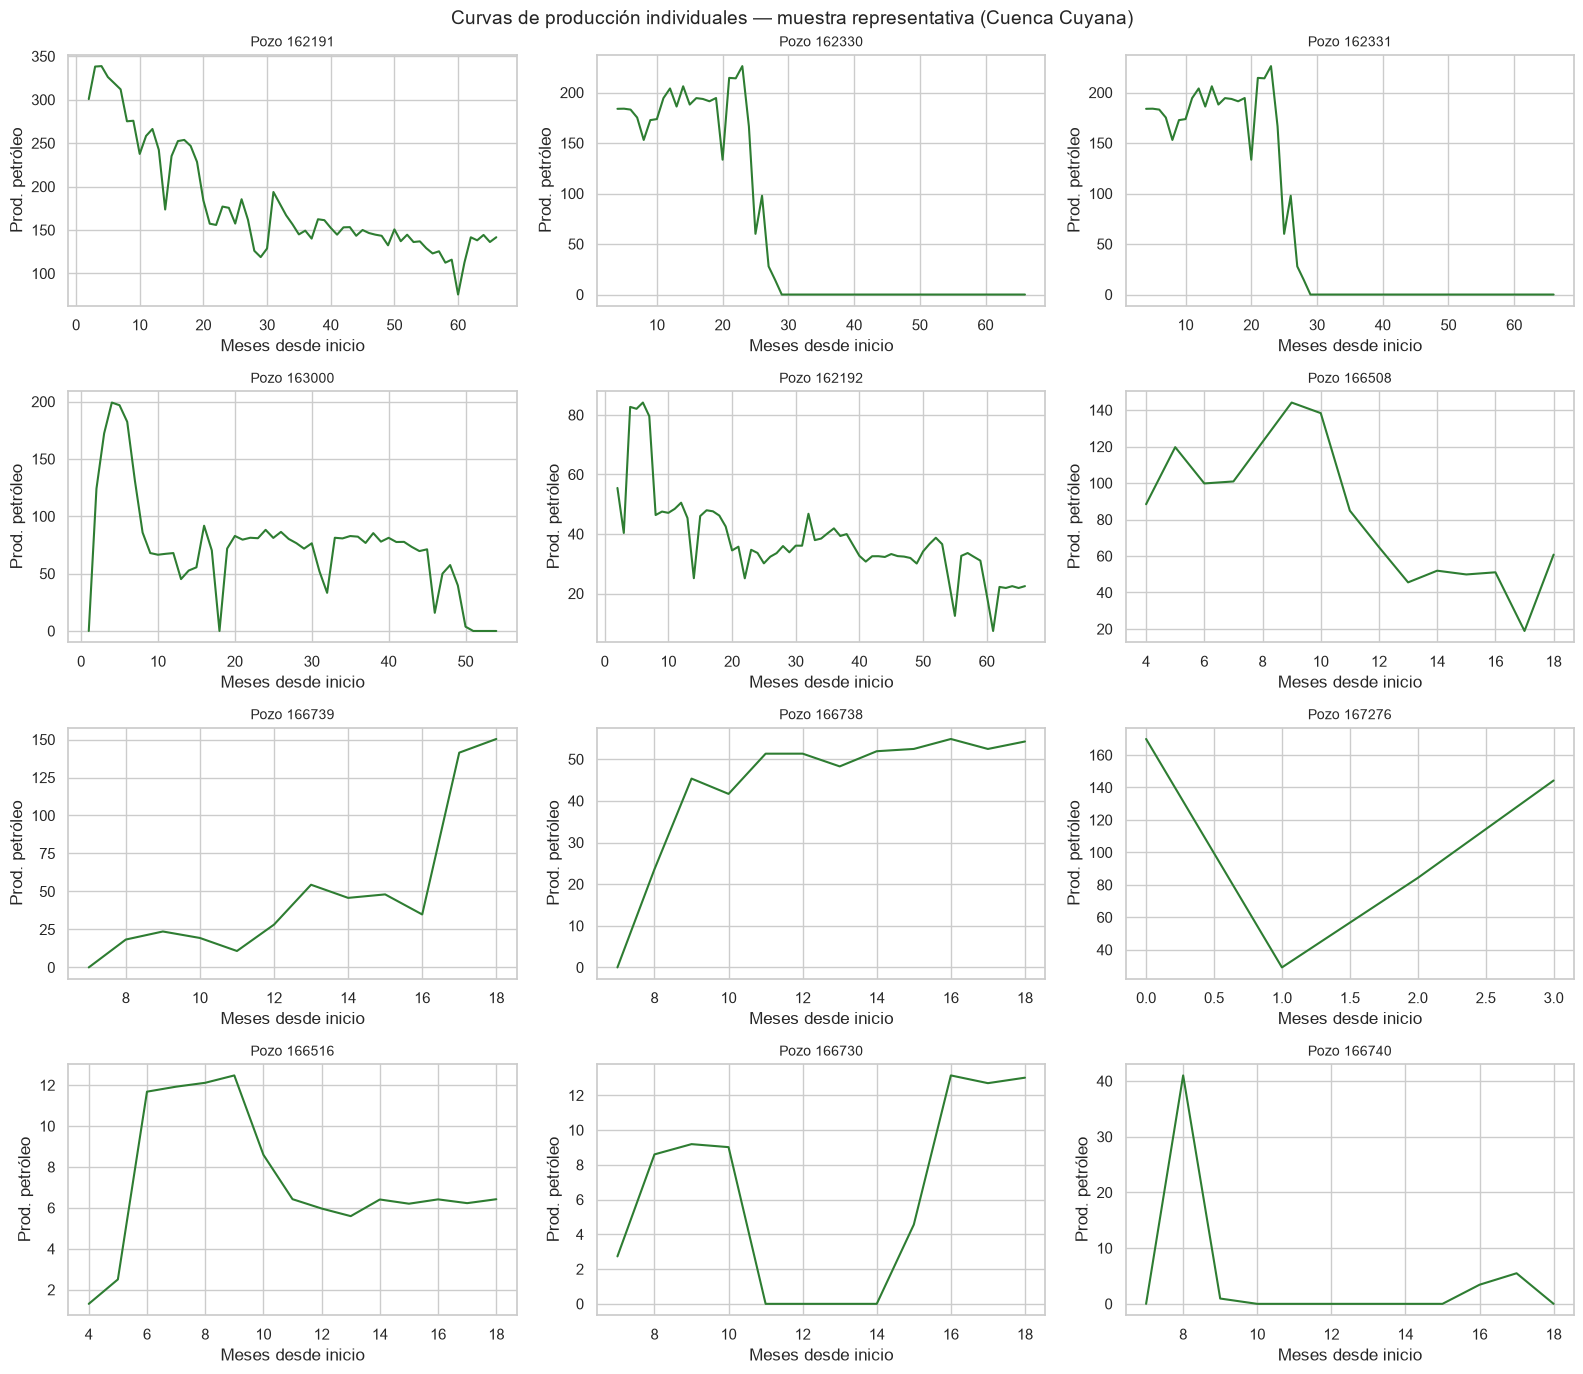

In [43]:

fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharex=False)
axes = axes.flatten()

for i, pozo in enumerate(muestra_rampup):
    datos_pozo = df_micro_curvas[df_micro_curvas['idpozo'] == pozo].sort_values('meses_desde_inicio')
    axes[i].plot(datos_pozo['meses_desde_inicio'], datos_pozo['prod_pet'], color='#2E7D32')
    axes[i].set_title(f"Pozo {pozo}", fontsize=10)
    axes[i].set_xlabel("Meses desde inicio")
    axes[i].set_ylabel("Prod. petróleo")

plt.suptitle("Curvas de producción individuales — muestra representativa (Cuenca Cuyana)", fontsize=14)
plt.tight_layout()
plt.show()

### Observaciones — Curvas de producción por pozo, ramp-up real (Línea 2)

**Patrones de ramp-up identificados:**

1. **Ramp-up clásico (subida rápida → pico → declive):** los pozos 163000, 166508 
   y 166516 muestran el patrón textbook — alcanzan su pico en los primeros 
   5-10 meses y luego declinan de forma más o menos suave, con oscilaciones 
   propias de la operación (paradas, mantenimiento).

2. **Pico muy temprano seguido de abandono/corte abrupto:** los pozos 162330 y 
   162331 muestran una meseta sostenida de producción y luego una **caída 
   vertical a cero** alrededor del mes 28-30. Esto no parece declinación 
   natural (que sería gradual), sino más bien un **cierre operativo del pozo** 
   (abandono, taponamiento, o fin de la ventana de datos disponible para ese 
   pozo). Hay que diferenciar esto de una declinación real antes de usarlo 
   como ejemplo de "ramp-up típico".

3. **Pico ya alcanzado desde el inicio del registro:** el pozo 162191 arranca 
   ya en su valor más alto (~350) y declina desde el primer mes. Esto sugiere 
   que el verdadero ramp-up de este pozo ocurrió **antes** del primer registro 
   mensual disponible (quizás en cuestión de días/semanas, no meses), por lo 
   que para este pozo `meses_hasta_pico` sería prácticamente 0 o 1.

4. **Pozos que todavía no llegaron al pico (censura por la derecha):** 166738 
   y 166739 muestran una tendencia **creciente sin haber declinado todavía** 
   dentro de la ventana de datos disponible (18 meses). Estos pozos son 
   demasiado recientes para calcular su `meses_hasta_pico` de forma confiable 
   — su pico real podría ocurrir después del último dato que tenemos.

5. **Series cortas o erráticas, poco confiables:** el pozo 167276 solo tiene 
   3 puntos de datos, insuficiente para caracterizar ningún patrón. Los 
   pozos 166730 y 166740 muestran caídas a cero y recuperaciones abruptas 
   en medio de la serie, que podrían ser paradas temporales de producción 
   (no fin de vida del pozo) o posibles inconsistencias de carga de datos.

**Primeras hipótesis para Feature Engineering:**
- No todos los 42 pozos "nuevos" son aptos para calcular `meses_hasta_pico`: 
  hay que definir un **mínimo de meses de historial** (ej. al menos 12-18 
  meses post-declinación visible) para excluir los censurados por la derecha 
  (caso 4) antes de calcular la variable objetivo.
- Los ceros intermedios (caso 5) no deberían tratarse igual que "fin de vida 
  del pozo" — conviene revisar si son paradas operativas reales o gaps de 
  reporte, ya que un cero mal interpretado podría hacer que el algoritmo de 
  detección de pico elija un máximo local equivocado.
- La distinción entre "declinación natural" (caso 1) y "corte abrupto/abandono" 
  (caso 2) podría ser en sí misma una variable categórica interesante a 
  incorporar más adelante (tipo de fin de curva), no solo el tiempo hasta el pico.